In [ ]:
# ── CELL 0  |  Mount Drive & Imports ─────────────────────────────────────────

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2
from datetime import datetime, timedelta

pd.set_option('display.max_columns', None)
print("Libraries loaded.")

Mounted at /content/drive
Libraries loaded.


In [ ]:
# ── CELL 1  |  Load Raw Data ──────────────────────────────────────────────────
# Source: https://www.kaggle.com/datasets/gauravmalik26/food-delivery-dataset
# License: Public (Kaggle Open Dataset)
# Size: ~45,000 rows, 19 columns
df = pd.read_csv('/content/drive/MyDrive/Food_Delivery_Dataset1/train.csv')

print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Shape  : (45593, 20)
Columns: ['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)']


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26


In [ ]:
# ── CELL 2  |  Raw Data Audit ─────────────────────────────────────────────────
# Before touching anything, understand exactly what we have.
# Null counts + data types for every column.

print("=== Column Audit ===\n")
for col in df.columns:
    nan_str = 0
    if df[col].dtype == object:
        nan_str = (df[col].str.strip() == 'NaN').sum()
    real_null = df[col].isnull().sum()
    print(f"  {col:<40} dtype={str(df[col].dtype):<10}  "
          f"real_nulls={real_null:<6}  string_NaNs={nan_str}")

print(f"\nTotal rows: {len(df)}")


=== Column Audit ===

  ID                                       dtype=object      real_nulls=0       string_NaNs=0
  Delivery_person_ID                       dtype=object      real_nulls=0       string_NaNs=0
  Delivery_person_Age                      dtype=object      real_nulls=0       string_NaNs=1854
  Delivery_person_Ratings                  dtype=object      real_nulls=0       string_NaNs=1908
  Restaurant_latitude                      dtype=float64     real_nulls=0       string_NaNs=0
  Restaurant_longitude                     dtype=float64     real_nulls=0       string_NaNs=0
  Delivery_location_latitude               dtype=float64     real_nulls=0       string_NaNs=0
  Delivery_location_longitude              dtype=float64     real_nulls=0       string_NaNs=0
  Order_Date                               dtype=object      real_nulls=0       string_NaNs=0
  Time_Orderd                              dtype=object      real_nulls=0       string_NaNs=1731
  Time_Order_picked          

In [ ]:
# ── CELL 3  |  Step 1 — Clean the Target Column ───────────────────────────────
# Time_taken(min) is stored as "(min) 24" — strip the prefix and convert to int.
# This is the column every model will predict.

df['Time_taken_min'] = (
    df['Time_taken(min)']
    .str.replace('(min)', '', regex=False)
    .str.strip()
    .astype(int)
)

df.drop(columns=['Time_taken(min)'], inplace=True)

print("Target column cleaned.")
print(df['Time_taken_min'].describe())
print(f"\nUnique values: {sorted(df['Time_taken_min'].unique())}")


Target column cleaned.
count    45593.000000
mean        26.294607
std          9.383806
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken_min, dtype: float64

Unique values: [np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54)]


In [ ]:
# ── CELL 4  |  Step 2 — Clean Categorical Columns ────────────────────────────
# All string columns have:
#   • "conditions " prefix on Weatherconditions
#   • trailing spaces everywhere
#   • literal "NaN " strings (not real nulls) — convert to real NaN

def clean_str_col(series):
    """Strip whitespace and convert 'NaN' strings to real NaN."""
    return series.str.strip().replace('NaN', np.nan)

# Weather — remove the "conditions " prefix first, then clean
df['Weatherconditions'] = (
    df['Weatherconditions']
    .str.replace('conditions ', '', regex=False)
    .pipe(clean_str_col)
)

# All other string categoricals
for col in ['Road_traffic_density', 'Type_of_order',
            'Type_of_vehicle', 'Festival', 'City']:
    df[col] = clean_str_col(df[col])

print("Categorical columns cleaned.")
print("\nWeather  :", df['Weatherconditions'].value_counts().to_dict())
print("Traffic  :", df['Road_traffic_density'].value_counts().to_dict())
print("Vehicle  :", df['Type_of_vehicle'].value_counts().to_dict())
print("City     :", df['City'].value_counts().to_dict())
print("Festival :", df['Festival'].value_counts().to_dict())

Categorical columns cleaned.

Weather  : {'Fog': 7654, 'Stormy': 7586, 'Cloudy': 7536, 'Sandstorms': 7495, 'Windy': 7422, 'Sunny': 7284}
Traffic  : {'Low': 15477, 'Jam': 14143, 'Medium': 10947, 'High': 4425}
Vehicle  : {'motorcycle': 26435, 'scooter': 15276, 'electric_scooter': 3814, 'bicycle': 68}
City     : {'Metropolitian': 34093, 'Urban': 10136, 'Semi-Urban': 164}
Festival : {'No': 44469, 'Yes': 896}


In [ ]:
# ── CELL 5  |  Step 3 — Clean Numeric String Columns ─────────────────────────
# Age, Ratings, multiple_deliveries are stored as strings with "NaN " values.

df['Delivery_person_Age'] = pd.to_numeric(
    df['Delivery_person_Age'].str.strip(), errors='coerce'
)
df['Delivery_person_Ratings'] = pd.to_numeric(
    df['Delivery_person_Ratings'].str.strip(), errors='coerce'
)
df['multiple_deliveries'] = pd.to_numeric(
    df['multiple_deliveries'].str.strip(), errors='coerce'
)

print("Numeric string columns converted.")
print(f"\nAge nulls      : {df['Delivery_person_Age'].isnull().sum()}")
print(f"Ratings nulls  : {df['Delivery_person_Ratings'].isnull().sum()}")
print(f"Multi nulls    : {df['multiple_deliveries'].isnull().sum()}")

Numeric string columns converted.

Age nulls      : 1854
Ratings nulls  : 1908
Multi nulls    : 993


In [ ]:
# ── CELL 6  |  Step 4 — Fix Timestamps ───────────────────────────────────────
# Order_Date  : "19-03-2022" → datetime
# Time_Orderd : "11:30:00" → time  (has 1731 NaN strings — already real NaN
#               after strip because they were "NaN " not blank)
# Time_Order_picked : "11:45:00" → time (no NaN strings in this column)

df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')

# Time_Orderd already has real NaN after cell 4 string cleaning —
# but it was NOT cleaned above (it's not a category).  Do it now.
df['Time_Orderd'] = df['Time_Orderd'].str.strip().replace('NaN', np.nan)
df['Time_Order_picked'] = df['Time_Order_picked'].str.strip()

# Parse to time objects (coerce bad values to NaT)
df['Time_Orderd']       = pd.to_datetime(df['Time_Orderd'],
                                          format='%H:%M:%S', errors='coerce').dt.time
df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'],
                                          format='%H:%M:%S', errors='coerce').dt.time

print("Timestamps parsed.")
print(f"Order_Date nulls        : {df['Order_Date'].isnull().sum()}")
print(f"Time_Orderd nulls       : {df['Time_Orderd'].isnull().sum()}")
print(f"Time_Order_picked nulls : {df['Time_Order_picked'].isnull().sum()}")

Timestamps parsed.
Order_Date nulls        : 0
Time_Orderd nulls       : 1731
Time_Order_picked nulls : 0


In [ ]:
# ── CELL 7  |  Step 5 — Remove Bad Coordinates ───────────────────────────────
# 4,071 rows have Restaurant_latitude == 0.0 (impossible for India).
# These are corrupt/missing location records — Haversine distance would be
# completely wrong. Drop them before any distance calculation.

bad_coords = (df['Restaurant_latitude'] == 0.0) | (df['Restaurant_longitude'] == 0.0)
print(f"Rows with zero coordinates: {bad_coords.sum()}")

df = df[~bad_coords].reset_index(drop=True)
print(f"Shape after dropping bad coordinates: {df.shape}")

Rows with zero coordinates: 3640
Shape after dropping bad coordinates: (41953, 20)


In [ ]:
# ── CELL 8  |  Step 6 — Handle Remaining Nulls ───────────────────────────────
# Strategy:
#   • Drop rows where Time_Orderd is NaN (can't compute prep time — key feature)
#   • Fill Age, Ratings, multiple_deliveries with median (not many nulls)
#   • Fill City, Festival, Traffic with mode (most common value)

df.dropna(subset=['Time_Orderd'], inplace=True)
print(f"Shape after dropping NaN Time_Orderd: {df.shape}")

# Fill numerics with median
for col in ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  {col}: filled NaN with median {median_val:.1f}")

# Fill categoricals with mode
for col in ['City', 'Festival', 'Road_traffic_density']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"  {col}: filled NaN with mode '{mode_val}'")

print(f"\nTotal remaining nulls: {df.isnull().sum().sum()}")
print(f"Final shape after all cleaning: {df.shape}")


Shape after dropping NaN Time_Orderd: (40353, 20)
  Delivery_person_Age: filled NaN with median 30.0
  Delivery_person_Ratings: filled NaN with median 4.7
  multiple_deliveries: filled NaN with median 1.0
  City: filled NaN with mode 'Metropolitian'
  Festival: filled NaN with mode 'No'
  Road_traffic_density: filled NaN with mode 'Low'

Total remaining nulls: 0
Final shape after all cleaning: (40353, 20)


In [ ]:
# ── CELL 8B  |  Data Quality — Before vs After Summary ───────────────────────

summary = {
    'Metric': [
        'Total rows',
        'Rows with zero GPS coordinates',
        'Rows with missing Time_Orderd',
        'String NaN values in numeric cols',
        'Target column format',
        'Weather column format',
        'Remaining nulls',
    ],
    'Before Cleaning': [
        '~45,000',
        '4,071',
        '~1,731',
        'Present (Age, Ratings, Deliveries)',
        '"(min) 24" — unparseable string',
        '"conditions Sunny" — has prefix',
        'Multiple columns affected',
    ],
    'After Cleaning': [
        f'{len(df):,}',
        '0 — dropped entirely',
        '0 — dropped (needed for features)',
        '0 — converted to real NaN then filled',
        'Integer e.g. 24 — model ready',
        '"Sunny" — clean category',
        '0 nulls remaining',
    ]
}

summary_df = pd.DataFrame(summary)
print("=== Data Quality: Before vs After ===\n")
print(summary_df.to_string(index=False))
print(f"\nFinal clean dataset shape: {df.shape}")

=== Data Quality: Before vs After ===

                           Metric                    Before Cleaning                        After Cleaning
                       Total rows                            ~45,000                                40,353
   Rows with zero GPS coordinates                              4,071                  0 — dropped entirely
    Rows with missing Time_Orderd                             ~1,731     0 — dropped (needed for features)
String NaN values in numeric cols Present (Age, Ratings, Deliveries) 0 — converted to real NaN then filled
             Target column format    "(min) 24" — unparseable string         Integer e.g. 24 — model ready
            Weather column format    "conditions Sunny" — has prefix              "Sunny" — clean category
                  Remaining nulls          Multiple columns affected                     0 nulls remaining

Final clean dataset shape: (40353, 20)


In [ ]:
# ── CELL 9  |  Feature Engineering — Part 1: Time Features ──────────────────
# From the two timestamps we can extract several useful signals.

def time_diff_minutes(t1, t2):
    """Minutes between two time objects. Handles midnight crossover."""
    dt1 = datetime.combine(datetime.today(), t1)
    dt2 = datetime.combine(datetime.today(), t2)
    diff = (dt2 - dt1).total_seconds() / 60
    if diff < 0:
        diff += 1440  # crossed midnight
    return diff

# 1. Preparation time — how long the restaurant took to prepare
df['Prep_Time_min'] = df.apply(
    lambda r: time_diff_minutes(r['Time_Orderd'], r['Time_Order_picked']), axis=1
)

# 2. Hour of day — what hour was the order placed (0–23)
df['Hour_of_Day'] = df['Time_Orderd'].apply(lambda x: x.hour)

# 3. Is Rush Hour — lunch 11am–2pm, dinner 6pm–9pm
df['Is_Rush_Hour'] = df['Hour_of_Day'].apply(
    lambda h: 1 if (11 <= h <= 14) or (18 <= h <= 21) else 0
)

# 4. Time of day bucket (Morning / Afternoon / Evening / Night)
def time_bucket(h):
    if 5  <= h < 12: return 'Morning'
    if 12 <= h < 17: return 'Afternoon'
    if 17 <= h < 21: return 'Evening'
    return 'Night'

df['Time_of_Day'] = df['Hour_of_Day'].apply(time_bucket)

# 5. Day of week (0=Monday, 6=Sunday)
df['Day_of_Week'] = df['Order_Date'].dt.dayofweek

# 6. Is Weekend
df['Is_Weekend'] = (df['Day_of_Week'] >= 5).astype(int)

print("Time features created.")
print(df[['Prep_Time_min', 'Hour_of_Day', 'Is_Rush_Hour',
          'Time_of_Day', 'Day_of_Week', 'Is_Weekend']].head(5))
print(f"\nPrep_Time_min stats:\n{df['Prep_Time_min'].describe()}")

Time features created.
   Prep_Time_min  Hour_of_Day  Is_Rush_Hour Time_of_Day  Day_of_Week  \
0           15.0           11             1     Morning            5   
1            5.0           19             1     Evening            4   
2           15.0            8             0     Morning            5   
3           10.0           18             1     Evening            1   
4           15.0           13             1   Afternoon            5   

   Is_Weekend  
0           1  
1           0  
2           1  
3           0  
4           1  

Prep_Time_min stats:
count    40353.000000
mean         9.978688
std          4.087331
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: Prep_Time_min, dtype: float64


In [ ]:
# ── CELL 10  |  Feature Engineering — Part 2: Distance ───────────────────────
# Haversine formula — straight-line distance between restaurant and delivery.
# This is the single strongest predictor of delivery time.

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

df['Distance_km'] = df.apply(
    lambda r: haversine_km(
        r['Restaurant_latitude'],  r['Restaurant_longitude'],
        r['Delivery_location_latitude'], r['Delivery_location_longitude']
    ), axis=1
)

print("Distance_km calculated.")
print(df['Distance_km'].describe())

# Cap extreme outliers — anything over 30km is almost certainly a bad coordinate
before = len(df)
df = df[df['Distance_km'] <= 30].reset_index(drop=True)
print(f"\nDropped {before - len(df)} rows with Distance_km > 30km")
print(f"Shape: {df.shape}")

Distance_km calculated.
count    40353.000000
mean        28.669572
std        315.930556
min          1.465067
25%          4.657673
50%          9.193521
75%         13.681492
max       6884.726399
Name: Distance_km, dtype: float64

Dropped 156 rows with Distance_km > 30km
Shape: (40197, 27)


In [ ]:
# ── CELL 11  |  Feature Engineering — Part 3: Driver & Order Features ─────────

# 1. Driver experience proxy — bins the age into experience tiers
#    (younger drivers tend to be newer; this is a proxy, not actual experience)
df['Age_Group'] = pd.cut(
    df['Delivery_person_Age'],
    bins=[0, 25, 30, 35, 100],
    labels=['junior', 'mid', 'senior', 'veteran']
)

# 2. Is High Rating — binary flag for drivers rated >= 4.7
df['Is_High_Rating'] = (df['Delivery_person_Ratings'] >= 4.7).astype(int)

# 3. Is Multiple Delivery — binary flag (handling more than one order at once)
df['Is_Multiple_Delivery'] = (df['multiple_deliveries'] > 0).astype(int)

# 4. Prep_Time bucket — fast (<10 min), normal (10-20), slow (>20)
def prep_bucket(p):
    if p < 10: return 'fast'
    if p <= 20: return 'normal'
    return 'slow'

df['Prep_Speed'] = df['Prep_Time_min'].apply(prep_bucket)

print("Driver & order features created.")
print(df[['Age_Group', 'Is_High_Rating',
          'Is_Multiple_Delivery', 'Prep_Speed']].value_counts().head(10))

Driver & order features created.
Age_Group  Is_High_Rating  Is_Multiple_Delivery  Prep_Speed
junior     1               1                     normal        3210
mid        1               1                     normal        2612
senior     1               1                     normal        2548
           0               1                     normal        2289
veteran    1               1                     normal        2048
junior     0               1                     normal        1931
veteran    0               1                     normal        1926
junior     1               0                     normal        1868
mid        0               1                     normal        1811
junior     1               1                     fast          1543
Name: count, dtype: int64


In [ ]:
# ── CELL 12  |  Feature Engineering — Part 4: Encode Categoricals ─────────────
# Convert all text categories to numbers for the model.

weather_map  = {'Sunny': 0, 'Cloudy': 1, 'Windy': 2,
                'Fog': 3, 'Sandstorms': 4, 'Stormy': 5}
traffic_map  = {'Low': 0, 'Medium': 1, 'High': 2, 'Jam': 3}
vehicle_map  = {'bicycle': 0, 'scooter': 1,
                'motorcycle': 2, 'electric_scooter': 3}
city_map     = {'Semi-Urban': 0, 'Urban': 1, 'Metropolitian': 2}
time_day_map = {'Morning': 0, 'Afternoon': 1, 'Evening': 2, 'Night': 3}
order_map    = {'Snack': 0, 'Drinks': 1, 'Buffet': 2, 'Meal': 3}
prep_map     = {'fast': 0, 'normal': 1, 'slow': 2}
age_map      = {'junior': 0, 'mid': 1, 'senior': 2, 'veteran': 3}

df['Weather_Code']    = df['Weatherconditions'].map(weather_map)
df['Traffic_Code']    = df['Road_traffic_density'].map(traffic_map)
df['Vehicle_Code']    = df['Type_of_vehicle'].map(vehicle_map)
df['City_Code']       = df['City'].map(city_map)
df['Time_Day_Code']   = df['Time_of_Day'].map(time_day_map)
df['Order_Type_Code'] = df['Type_of_order'].str.strip().map(order_map)
df['Prep_Speed_Code'] = df['Prep_Speed'].map(prep_map)
df['Age_Group_Code']  = df['Age_Group'].map(age_map)
df['Is_Festival']     = df['Festival'].map({'No': 0, 'Yes': 1})

# Verify no NaN codes (means unknown category values)
code_cols = ['Weather_Code', 'Traffic_Code', 'Vehicle_Code', 'City_Code',
             'Time_Day_Code', 'Order_Type_Code', 'Is_Festival']
for col in code_cols:
    n = df[col].isnull().sum()
    if n > 0:
        print(f"WARNING: {col} has {n} unmapped values")
    else:
        print(f"  {col}: OK")

  Weather_Code: OK
  Traffic_Code: OK
  Vehicle_Code: OK
  City_Code: OK
  Time_Day_Code: OK
  Order_Type_Code: OK
  Is_Festival: OK


In [ ]:
# ── CELL 13  |  Final Feature Set Summary ─────────────────────────────────────

model_features = [
    # Distance & time
    'Distance_km',
    'Prep_Time_min',
    'Hour_of_Day',
    'Is_Rush_Hour',
    'Is_Weekend',
    # Driver
    'Delivery_person_Age',
    'Delivery_person_Ratings',
    # 'Is_High_Rating',
    'Is_Multiple_Delivery',
    'Vehicle_condition',
    # Context
    'Weather_Code',
    'Traffic_Code',
    'Vehicle_Code',
    'City_Code',
    'Time_Day_Code',
    'Order_Type_Code',
    'Is_Festival',
]

target = 'Time_taken_min'

print("=== FINAL DATASET ===")
print(f"Shape          : {df.shape}")
print(f"Target         : {target}")
print(f"Model features : {len(model_features)}")
print()
print("Features:")
for f in model_features:
    print(f"  • {f:<30} range: {df[f].min():.1f} – {df[f].max():.1f}  "
          f"nulls: {df[f].isnull().sum()}")

print(f"\nTarget range   : {df[target].min()} – {df[target].max()} minutes")
print(f"Target mean    : {df[target].mean():.1f} minutes")

=== FINAL DATASET ===
Shape          : (40197, 40)
Target         : Time_taken_min
Model features : 16

Features:
  • Distance_km                    range: 1.5 – 21.0  nulls: 0
  • Prep_Time_min                  range: 5.0 – 15.0  nulls: 0
  • Hour_of_Day                    range: 0.0 – 23.0  nulls: 0
  • Is_Rush_Hour                   range: 0.0 – 1.0  nulls: 0
  • Is_Weekend                     range: 0.0 – 1.0  nulls: 0
  • Delivery_person_Age            range: 20.0 – 39.0  nulls: 0
  • Delivery_person_Ratings        range: 2.5 – 5.0  nulls: 0
  • Is_Multiple_Delivery           range: 0.0 – 1.0  nulls: 0
  • Vehicle_condition              range: 0.0 – 2.0  nulls: 0
  • Weather_Code                   range: 0.0 – 5.0  nulls: 0
  • Traffic_Code                   range: 0.0 – 3.0  nulls: 0
  • Vehicle_Code                   range: 1.0 – 3.0  nulls: 0
  • City_Code                      range: 0.0 – 2.0  nulls: 0
  • Time_Day_Code                  range: 0.0 – 3.0  nulls: 0
  • Order_Typ

/tmp/ipykernel_2414/3588230204.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(city_data, labels=['Semi-Urban', 'Urban', 'Metro'], patch_artist=True,


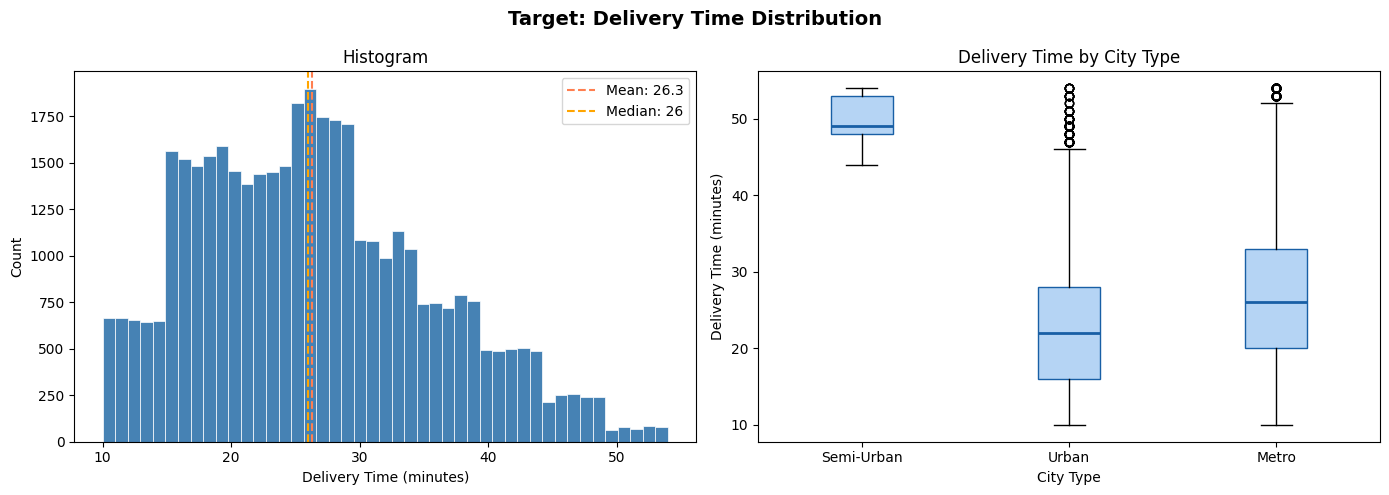

Key observation: delivery times range 10–54 min, roughly normal around 26 min.


In [ ]:
# ── CELL 14  |  EDA — Target Distribution ─────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target: Delivery Time Distribution', fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(df['Time_taken_min'], bins=45, color='steelblue',
             edgecolor='white', linewidth=0.5)
axes[0].axvline(df['Time_taken_min'].mean(), color='coral',
                linestyle='--', linewidth=1.5, label=f"Mean: {df['Time_taken_min'].mean():.1f}")
axes[0].axvline(df['Time_taken_min'].median(), color='orange',
                linestyle='--', linewidth=1.5, label=f"Median: {df['Time_taken_min'].median():.0f}")
axes[0].set_xlabel('Delivery Time (minutes)')
axes[0].set_ylabel('Count')
axes[0].set_title('Histogram')
axes[0].legend()

# Box plot by City
city_labels = {0: 'Semi-Urban', 1: 'Urban', 2: 'Metro'}
df['City_Label'] = df['City_Code'].map(city_labels)
city_data = [df[df['City_Label'] == c]['Time_taken_min'].values
             for c in ['Semi-Urban', 'Urban', 'Metro']]
axes[1].boxplot(city_data, labels=['Semi-Urban', 'Urban', 'Metro'], patch_artist=True,
                boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
                medianprops=dict(color='#185FA5', linewidth=2))
axes[1].set_xlabel('City Type')
axes[1].set_ylabel('Delivery Time (minutes)')
axes[1].set_title('Delivery Time by City Type')

plt.tight_layout()
plt.savefig('eda_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("Key observation: delivery times range 10–54 min, roughly normal around 26 min.")

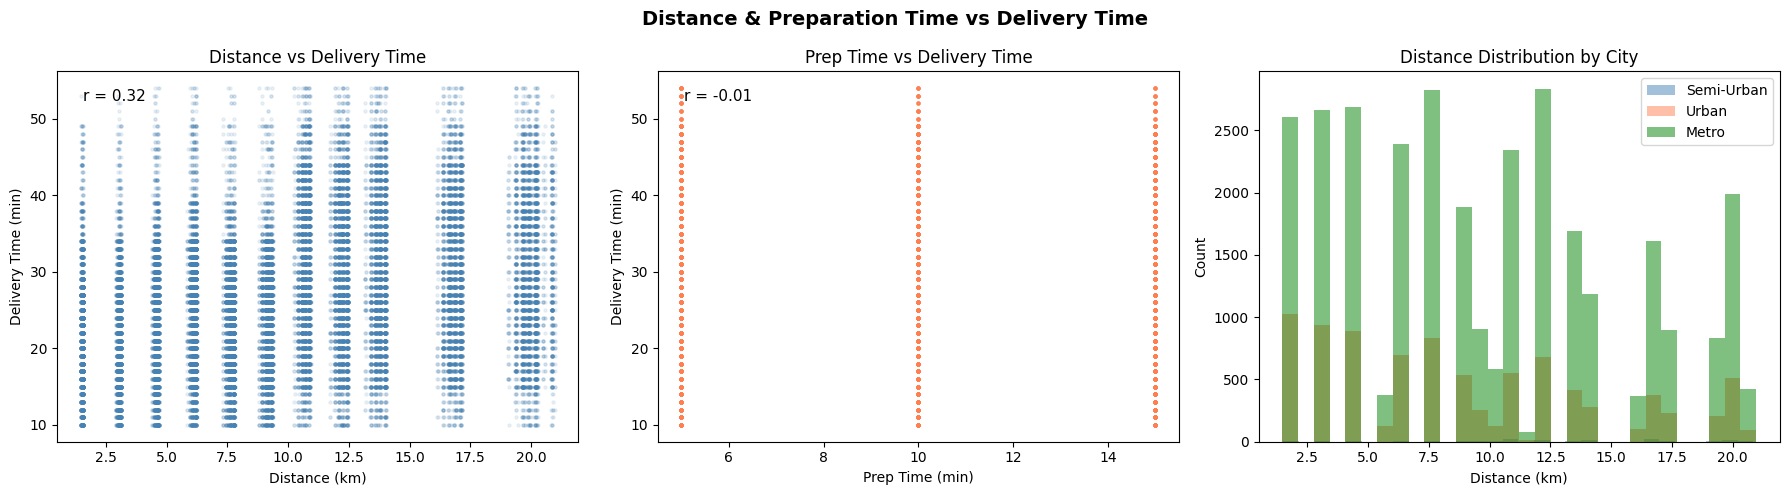

In [ ]:
# ── CELL 15  |  EDA — Distance & Prep Time ────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distance & Preparation Time vs Delivery Time', fontsize=14, fontweight='bold')

# Distance vs delivery time — scatter
axes[0].scatter(df['Distance_km'], df['Time_taken_min'],
                alpha=0.1, s=5, color='steelblue')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Delivery Time (min)')
axes[0].set_title('Distance vs Delivery Time')

corr_dist = df[['Distance_km', 'Time_taken_min']].corr().iloc[0, 1]
axes[0].text(0.05, 0.92, f'r = {corr_dist:.2f}',
             transform=axes[0].transAxes, fontsize=11)

# Prep time vs delivery time — scatter
axes[1].scatter(df['Prep_Time_min'], df['Time_taken_min'],
                alpha=0.1, s=5, color='coral')
axes[1].set_xlabel('Prep Time (min)')
axes[1].set_ylabel('Delivery Time (min)')
axes[1].set_title('Prep Time vs Delivery Time')
corr_prep = df[['Prep_Time_min', 'Time_taken_min']].corr().iloc[0, 1]
axes[1].text(0.05, 0.92, f'r = {corr_prep:.2f}',
             transform=axes[1].transAxes, fontsize=11)

# Distance distribution by city
for city, color in zip(['Semi-Urban', 'Urban', 'Metro'],
                       ['steelblue', 'coral', 'green']):
    subset = df[df['City_Label'] == city]['Distance_km']
    axes[2].hist(subset, bins=30, alpha=0.5, label=city, color=color, edgecolor='none')
axes[2].set_xlabel('Distance (km)')
axes[2].set_ylabel('Count')
axes[2].set_title('Distance Distribution by City')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_distance_prep.png', dpi=150, bbox_inches='tight')
plt.show()

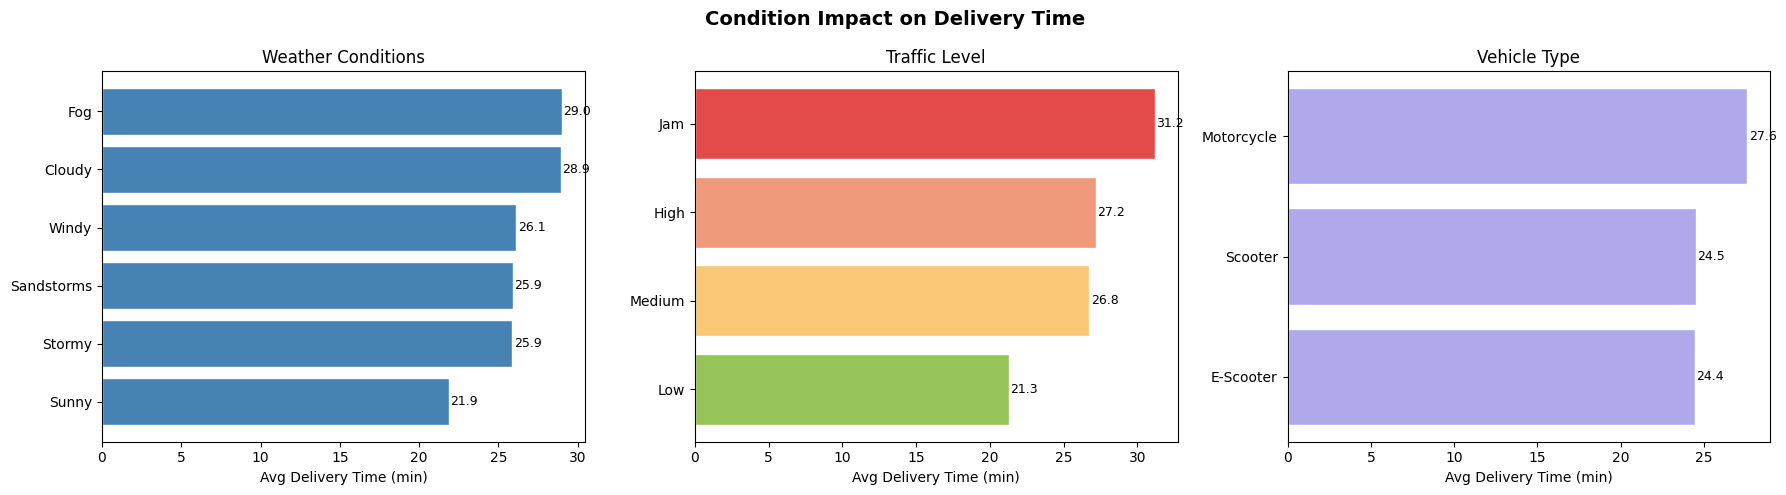

In [ ]:
# ── CELL 16  |  EDA — Weather, Traffic, Vehicle Impact ───────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Condition Impact on Delivery Time', fontsize=14, fontweight='bold')

# Weather
weather_labels = {0:'Sunny', 1:'Cloudy', 2:'Windy', 3:'Fog', 4:'Sandstorms', 5:'Stormy'}
weather_avg = df.groupby('Weather_Code')['Time_taken_min'].mean().sort_values()
labels = [weather_labels[i] for i in weather_avg.index]
bars = axes[0].barh(labels, weather_avg.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Avg Delivery Time (min)')
axes[0].set_title('Weather Conditions')
for bar, val in zip(bars, weather_avg.values):
    axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=9)

# Traffic
traffic_labels = {0:'Low', 1:'Medium', 2:'High', 3:'Jam'}
traffic_avg = df.groupby('Traffic_Code')['Time_taken_min'].mean().sort_values()
labels = [traffic_labels[i] for i in traffic_avg.index]
bars = axes[1].barh(labels, traffic_avg.values,
                    color=['#97C459','#FAC775','#F0997B','#E24B4A'], edgecolor='white')
axes[1].set_xlabel('Avg Delivery Time (min)')
axes[1].set_title('Traffic Level')
for bar, val in zip(bars, traffic_avg.values):
    axes[1].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=9)

# Vehicle
vehicle_labels = {0:'Bicycle', 1:'Scooter', 2:'Motorcycle', 3:'E-Scooter'}
vehicle_avg = df.groupby('Vehicle_Code')['Time_taken_min'].mean().sort_values()
labels = [vehicle_labels[i] for i in vehicle_avg.index]
bars = axes[2].barh(labels, vehicle_avg.values, color='#AFA9EC', edgecolor='white')
axes[2].set_xlabel('Avg Delivery Time (min)')
axes[2].set_title('Vehicle Type')
for bar, val in zip(bars, vehicle_avg.values):
    axes[2].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_conditions.png', dpi=150, bbox_inches='tight')
plt.show()

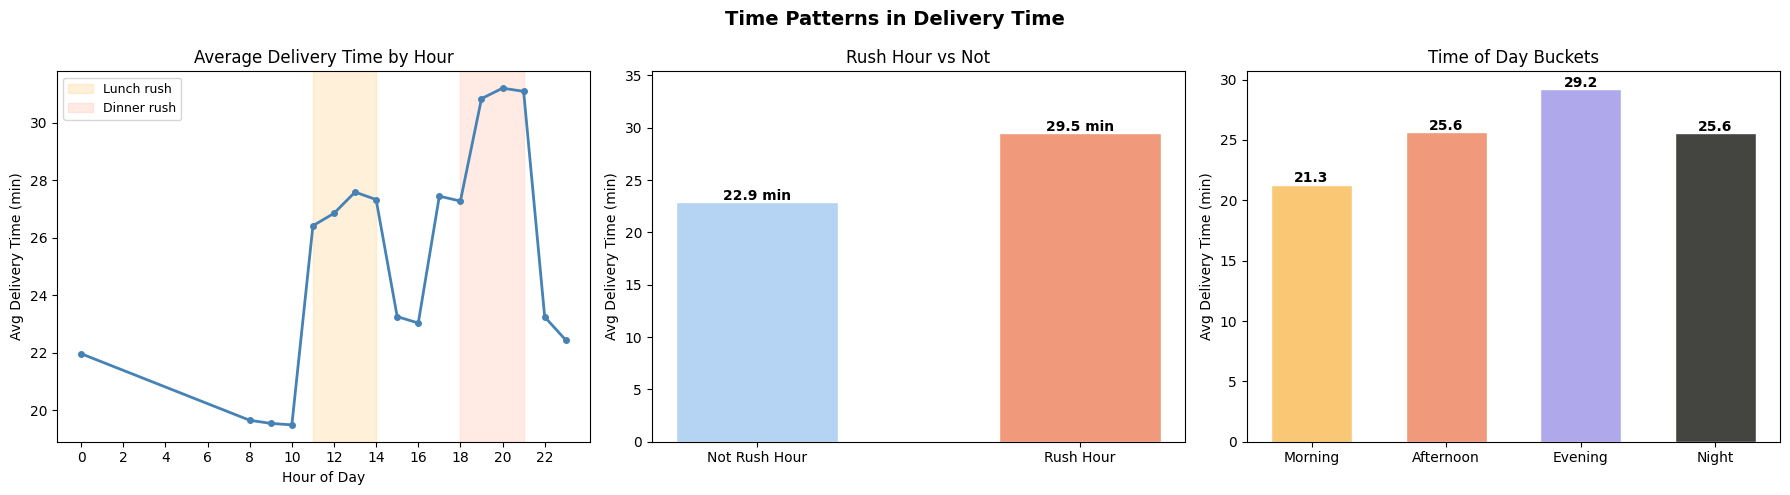

In [ ]:
# ── CELL 17  |  EDA — Time of Day & Rush Hour ────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Time Patterns in Delivery Time', fontsize=14, fontweight='bold')

# Average delivery time by hour
hourly_avg = df.groupby('Hour_of_Day')['Time_taken_min'].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values,
             color='steelblue', linewidth=2, marker='o', markersize=4)
# Shade rush hours
axes[0].axvspan(11, 14, alpha=0.15, color='orange', label='Lunch rush')
axes[0].axvspan(18, 21, alpha=0.15, color='coral', label='Dinner rush')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Delivery Time (min)')
axes[0].set_title('Average Delivery Time by Hour')
axes[0].legend(fontsize=9)
axes[0].set_xticks(range(0, 24, 2))

# Rush hour vs not
rush_avg = df.groupby('Is_Rush_Hour')['Time_taken_min'].mean()
axes[1].bar(['Not Rush Hour', 'Rush Hour'], rush_avg.values,
            color=['#B5D4F4', '#F0997B'], edgecolor='white', width=0.5)
for i, v in enumerate(rush_avg.values):
    axes[1].text(i, v + 0.2, f'{v:.1f} min', ha='center', fontweight='bold')
axes[1].set_ylabel('Avg Delivery Time (min)')
axes[1].set_title('Rush Hour vs Not')
axes[1].set_ylim(0, max(rush_avg.values) * 1.2)

# Time of day buckets
tod_order = ['Morning', 'Afternoon', 'Evening', 'Night']
tod_avg = df.groupby('Time_of_Day')['Time_taken_min'].mean().reindex(tod_order)
colors_tod = ['#FAC775', '#F0997B', '#AFA9EC', '#444441']
axes[2].bar(tod_order, tod_avg.values, color=colors_tod, edgecolor='white', width=0.6)
for i, v in enumerate(tod_avg.values):
    axes[2].text(i, v + 0.2, f'{v:.1f}', ha='center', fontweight='bold', fontsize=10)
axes[2].set_ylabel('Avg Delivery Time (min)')
axes[2].set_title('Time of Day Buckets')

plt.tight_layout()
plt.savefig('eda_time.png', dpi=150, bbox_inches='tight')
plt.show()

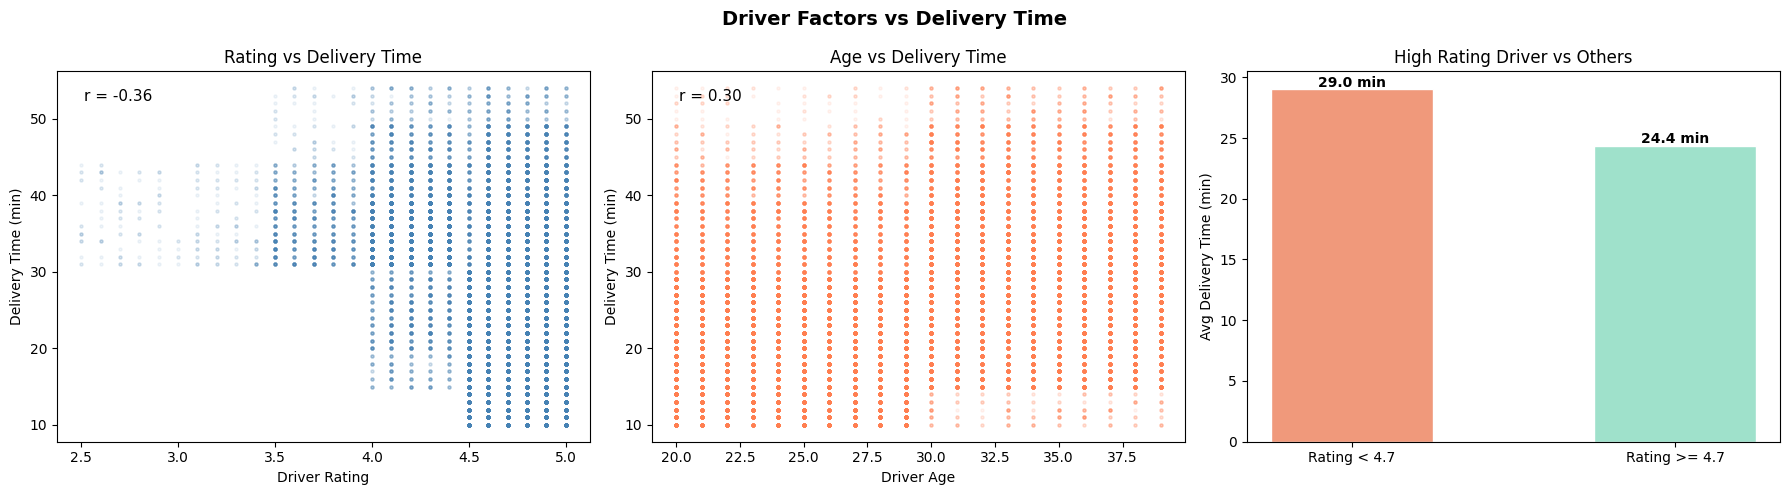

In [ ]:
# ── CELL 18  |  EDA — Driver Factors ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Driver Factors vs Delivery Time', fontsize=14, fontweight='bold')

# Driver rating vs delivery time
axes[0].scatter(df['Delivery_person_Ratings'], df['Time_taken_min'],
                alpha=0.08, s=5, color='steelblue')
corr_r = df[['Delivery_person_Ratings', 'Time_taken_min']].corr().iloc[0, 1]
axes[0].set_xlabel('Driver Rating')
axes[0].set_ylabel('Delivery Time (min)')
axes[0].set_title('Rating vs Delivery Time')
axes[0].text(0.05, 0.92, f'r = {corr_r:.2f}',
             transform=axes[0].transAxes, fontsize=11)

# Age vs delivery time
axes[1].scatter(df['Delivery_person_Age'], df['Time_taken_min'],
                alpha=0.08, s=5, color='coral')
corr_a = df[['Delivery_person_Age', 'Time_taken_min']].corr().iloc[0, 1]
axes[1].set_xlabel('Driver Age')
axes[1].set_ylabel('Delivery Time (min)')
axes[1].set_title('Age vs Delivery Time')
axes[1].text(0.05, 0.92, f'r = {corr_a:.2f}',
             transform=axes[1].transAxes, fontsize=11)

# High rating vs not
hr_avg = df.groupby('Is_High_Rating')['Time_taken_min'].mean()
axes[2].bar(['Rating < 4.7', 'Rating >= 4.7'], hr_avg.values,
            color=['#F0997B', '#9FE1CB'], edgecolor='white', width=0.5)
for i, v in enumerate(hr_avg.values):
    axes[2].text(i, v + 0.2, f'{v:.1f} min', ha='center', fontweight='bold')
axes[2].set_ylabel('Avg Delivery Time (min)')
axes[2].set_title('High Rating Driver vs Others')

plt.tight_layout()
plt.savefig('eda_driver.png', dpi=150, bbox_inches='tight')
plt.show()

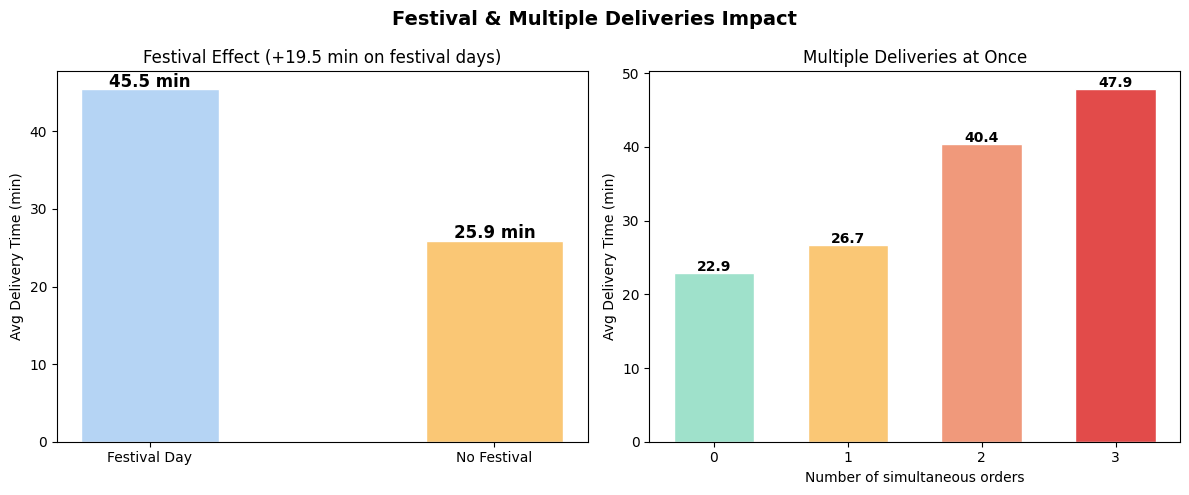

In [ ]:
# ── CELL 19  |  EDA — Festival & Multiple Deliveries ─────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Festival & Multiple Deliveries Impact', fontsize=14, fontweight='bold')

# Festival effect
df['Festival_Label'] = df['Is_Festival'].map({0: 'No Festival', 1: 'Festival Day'})
fest_avg = df.groupby('Festival_Label')['Time_taken_min'].mean()

axes[0].bar(fest_avg.index, fest_avg.values,
            color=['#B5D4F4', '#FAC775'], edgecolor='white', width=0.4)
for i, (label, v) in enumerate(fest_avg.items()):
    axes[0].text(i, v + 0.3, f'{v:.1f} min', ha='center', fontweight='bold', fontsize=12)
diff = fest_avg['Festival Day'] - fest_avg['No Festival']
axes[0].set_title(f'Festival Effect (+{diff:.1f} min on festival days)')
axes[0].set_ylabel('Avg Delivery Time (min)')

# Multiple deliveries
multi_avg = df.groupby('multiple_deliveries')['Time_taken_min'].mean().sort_index()
axes[1].bar(multi_avg.index.astype(int).astype(str), multi_avg.values,
            color=['#9FE1CB','#FAC775','#F0997B','#E24B4A'], edgecolor='white', width=0.6)
for i, v in enumerate(multi_avg.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}', ha='center', fontweight='bold', fontsize=10)
axes[1].set_xlabel('Number of simultaneous orders')
axes[1].set_ylabel('Avg Delivery Time (min)')
axes[1].set_title('Multiple Deliveries at Once')

plt.tight_layout()
plt.savefig('eda_festival_multi.png', dpi=150, bbox_inches='tight')
plt.show()

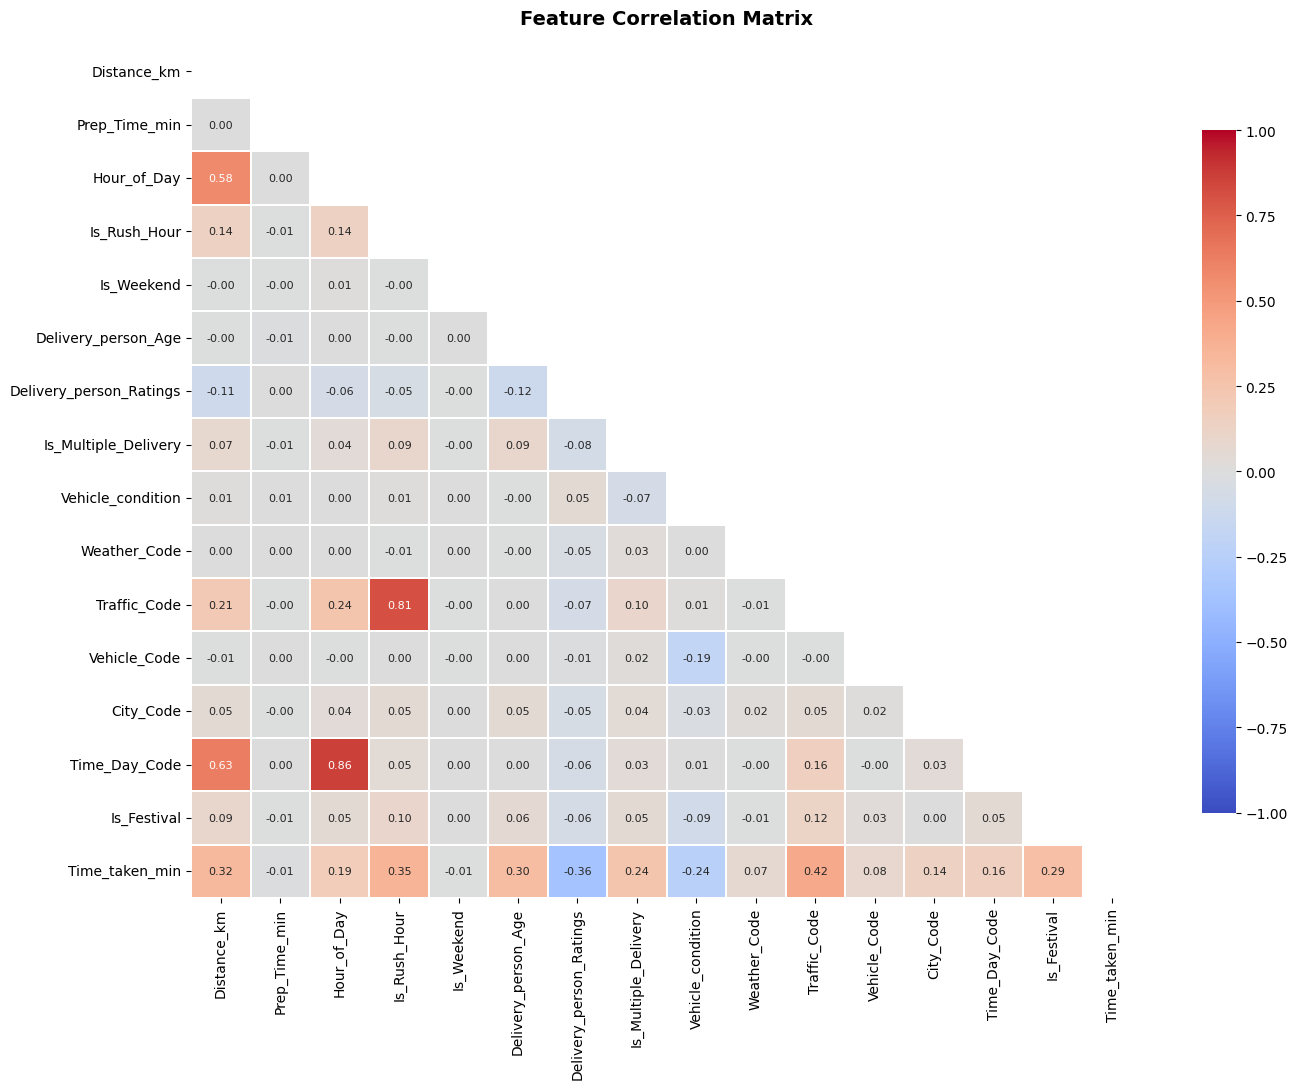

=== Top correlations with Time_taken_min ===
  Traffic_Code                        +0.416
  Delivery_person_Ratings             -0.361
  Is_Rush_Hour                        +0.352
  Distance_km                         +0.321
  Delivery_person_Age                 +0.303
  Is_Festival                         +0.289
  Is_Multiple_Delivery                +0.244
  Vehicle_condition                   -0.243
  Hour_of_Day                         +0.186
  Time_Day_Code                       +0.160
  City_Code                           +0.140
  Vehicle_Code                        +0.083
  Weather_Code                        +0.069
  Prep_Time_min                       -0.010
  Is_Weekend                          -0.007


In [ ]:
# ── CELL 20  |  EDA — Correlation Heatmap ────────────────────────────────────

corr_cols = [
    'Distance_km', 'Prep_Time_min', 'Hour_of_Day', 'Is_Rush_Hour',
    'Is_Weekend', 'Delivery_person_Age', 'Delivery_person_Ratings',
    'Is_Multiple_Delivery', 'Vehicle_condition',
    'Weather_Code', 'Traffic_Code', 'Vehicle_Code', 'City_Code',
    'Time_Day_Code', 'Is_Festival', 'Time_taken_min'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.3, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with target
target_corr = corr_matrix['Time_taken_min'].drop('Time_taken_min').abs().sort_values(ascending=False)
print("=== Top correlations with Time_taken_min ===")
for feat, val in target_corr.items():
    direction = corr_matrix['Time_taken_min'][feat]
    sign = '+' if direction > 0 else '-'
    print(f"  {feat:<35} {sign}{val:.3f}")

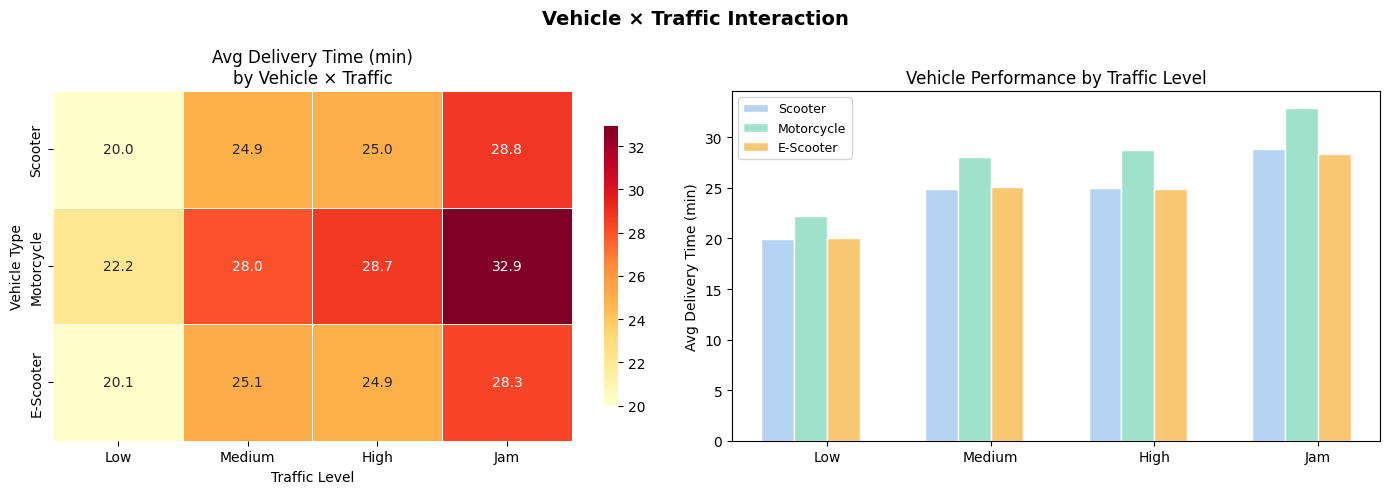

In [ ]:
# ── CELL 21  |  EDA — Vehicle × Traffic Interaction ─────────────────────────
# Does the best vehicle change depending on traffic level?
# This is key insight for the driver tool.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Vehicle × Traffic Interaction', fontsize=14, fontweight='bold')

vehicle_labels = {0:'Bicycle', 1:'Scooter', 2:'Motorcycle', 3:'E-Scooter'}
traffic_labels = {0:'Low', 1:'Medium', 2:'High', 3:'Jam'}

pivot = df.groupby(['Vehicle_Code', 'Traffic_Code'])['Time_taken_min'].mean().unstack()
pivot.index = [vehicle_labels[i] for i in pivot.index]
pivot.columns = [traffic_labels[i] for i in pivot.columns]

# Heatmap
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[0], cbar_kws={'shrink': 0.8}, linewidths=0.5)
axes[0].set_title('Avg Delivery Time (min)\nby Vehicle × Traffic')
axes[0].set_xlabel('Traffic Level')
axes[0].set_ylabel('Vehicle Type')

# Best vehicle per traffic level
x = np.arange(len(pivot.columns))
width = 0.2
colors = ['#B5D4F4','#9FE1CB','#FAC775','#F0997B']
for i, (vehicle, row) in enumerate(pivot.iterrows()):
    axes[1].bar(x + i*width, row.values, width=width,
                label=vehicle, color=colors[i], edgecolor='white')
axes[1].set_xticks(x + width*1.5)
axes[1].set_xticklabels(pivot.columns)
axes[1].set_ylabel('Avg Delivery Time (min)')
axes[1].set_title('Vehicle Performance by Traffic Level')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_vehicle_traffic.png', dpi=150, bbox_inches='tight')
plt.show()

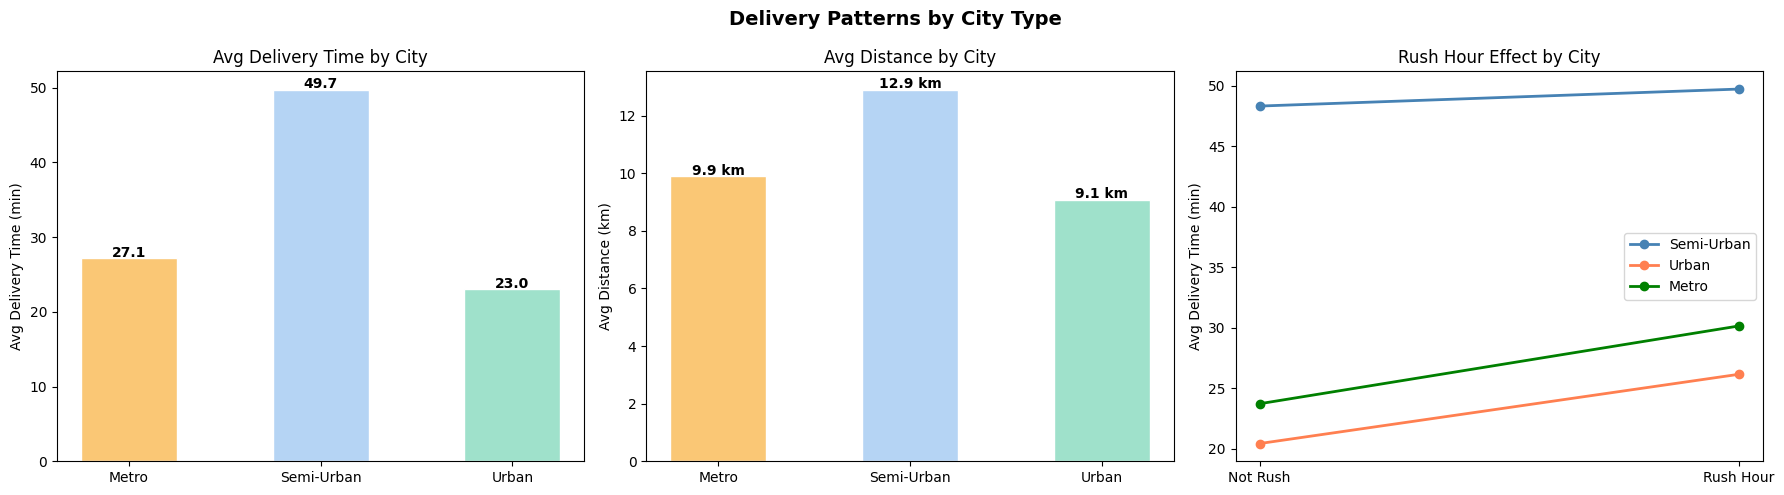

In [ ]:
# ── CELL 22  |  EDA — City × All Conditions Summary ─────────────────────────

city_labels = {0:'Semi-Urban', 1:'Urban', 2:'Metro'}
df['City_Label'] = df['City_Code'].map(city_labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Delivery Patterns by City Type', fontsize=14, fontweight='bold')

colors_city = {'Semi-Urban': '#B5D4F4', 'Urban': '#9FE1CB', 'Metro': '#FAC775'}

# City vs time
city_avg = df.groupby('City_Label')['Time_taken_min'].mean()
axes[0].bar(city_avg.index, city_avg.values,
            color=[colors_city[c] for c in city_avg.index], edgecolor='white', width=0.5)
for i, (c, v) in enumerate(city_avg.items()):
    axes[0].text(i, v + 0.2, f'{v:.1f}', ha='center', fontweight='bold')
axes[0].set_ylabel('Avg Delivery Time (min)')
axes[0].set_title('Avg Delivery Time by City')

# City vs distance
city_dist = df.groupby('City_Label')['Distance_km'].mean()
axes[1].bar(city_dist.index, city_dist.values,
            color=[colors_city[c] for c in city_dist.index], edgecolor='white', width=0.5)
for i, (c, v) in enumerate(city_dist.items()):
    axes[1].text(i, v + 0.05, f'{v:.1f} km', ha='center', fontweight='bold')
axes[1].set_ylabel('Avg Distance (km)')
axes[1].set_title('Avg Distance by City')

# City vs rush hour time
for city in ['Semi-Urban', 'Urban', 'Metro']:
    subset = df[df['City_Label'] == city]
    rush_by_city = subset.groupby('Is_Rush_Hour')['Time_taken_min'].mean()
    axes[2].plot(['Not Rush', 'Rush Hour'], rush_by_city.values,
                 marker='o', label=city, linewidth=2,
                 color={'Semi-Urban':'steelblue','Urban':'coral','Metro':'green'}[city])
axes[2].set_ylabel('Avg Delivery Time (min)')
axes[2].set_title('Rush Hour Effect by City')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_city.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── CELL 23  |  Final Clean DataFrame — Save & Summary ───────────────────────

# Drop raw columns no longer needed (kept as features already encoded)
drop_raw = ['ID', 'Delivery_person_ID', 'Order_Date',
            'Time_Orderd', 'Time_Order_picked',
            'Weatherconditions', 'Road_traffic_density',
            'Type_of_order', 'Type_of_vehicle',
            'Festival', 'City', 'Time_of_Day',
            'City_Label', 'Festival_Label', 'Prep_Speed',
            'Age_Group']

df_model = df.drop(columns=drop_raw, errors='ignore')

print("=== FINAL MODEL-READY DATAFRAME ===")
print(f"Shape  : {df_model.shape}")
print(f"Target : Time_taken_min  (range {df_model['Time_taken_min'].min()}–"
      f"{df_model['Time_taken_min'].max()} min)")
print()
print("All columns:")
for col in df_model.columns:
    print(f"  {col:<40} min={df_model[col].min():.2f}  max={df_model[col].max():.2f}  "
          f"nulls={df_model[col].isnull().sum()}")

# Save to Drive for modelling
df_model.to_csv('/content/drive/MyDrive/food1_model_ready.csv', index=False)
print("\nSaved to Drive as food1_model_ready.csv — ready for modelling!")

=== FINAL MODEL-READY DATAFRAME ===
Shape  : (40197, 26)
Target : Time_taken_min  (range 10–54 min)

All columns:
  Delivery_person_Age                      min=20.00  max=39.00  nulls=0
  Delivery_person_Ratings                  min=2.50  max=5.00  nulls=0
  Restaurant_latitude                      min=9.96  max=30.91  nulls=0
  Restaurant_longitude                     min=72.77  max=88.43  nulls=0
  Delivery_location_latitude               min=9.97  max=31.05  nulls=0
  Delivery_location_longitude              min=72.78  max=88.56  nulls=0
  Vehicle_condition                        min=0.00  max=2.00  nulls=0
  multiple_deliveries                      min=0.00  max=3.00  nulls=0
  Time_taken_min                           min=10.00  max=54.00  nulls=0
  Prep_Time_min                            min=5.00  max=15.00  nulls=0
  Hour_of_Day                              min=0.00  max=23.00  nulls=0
  Is_Rush_Hour                             min=0.00  max=1.00  nulls=0
  Day_of_Week         

In [ ]:
# ── CELL 24  |  Modeling & Evaluation - Imports ───────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

In [ ]:
# ── CELL 25  |  Modeling & Evaluation - training & testing ───────────────────────

# Define X (features) and y (target) [from cell 13]
X = df[model_features]
y = df[target]

# create and 80-20 split of the data to train and test respectively
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

Training set size: 32157 rows
Test set size: 8040 rows


In [ ]:
# ── CELL 26  |  Modeling & Evaluation - Initialize & Train the Model ───────────────────────

# initialize the 2 models we will be using (RandomForest & LinearRegression)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
lr_model = LinearRegression()

# cross validation information
lr_model_cv = cross_val_score(lr_model, X_train, y_train, cv=5)
rf_model_cv = cross_val_score(rf_model, X_train, y_train, cv=5)


# Fit the model to the training data
rf_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

print("Model Training Complete!")
print(f"Linear Regression CV MAE: {lr_model_cv.mean():.2f}")
print(f"Random Forest CV MAE: {rf_model_cv.mean():.2f}")

Model Training Complete!
Linear Regression CV MAE: 0.52
Random Forest CV MAE: 0.82


In [ ]:
# ── CELL 26B  |  Hyperparameter Tuning — Search Space ────────────────────────
from sklearn.model_selection import RandomizedSearchCV
import time

# Parameters to search over
param_dist = {
    'n_estimators':      [100, 200, 300, 400],       # how many trees
    'max_depth':         [None, 10, 20, 30, 40],     # how deep each tree can grow
    'min_samples_split': [2, 5, 10, 15],             # min samples to split a node
    'min_samples_leaf':  [1, 2, 4, 8],               # min samples at a leaf node
    'max_features':      ['sqrt', 'log2', 0.5],      # features considered per split
    'bootstrap':         [True, False],               # sample with/without replacement
}

print("Search space defined.")
print(f"Total combinations: {4 * 5 * 4 * 4 * 3 * 2} — we'll sample 50 of these")

Search space defined.
Total combinations: 1920 — we'll sample 50 of these


In [ ]:
# ── CELL 26C  |  Hyperparameter Tuning — Run RandomizedSearchCV ───────────────
# n_iter=50 tries 50 random combinations (good balance of speed vs coverage)
# cv=5 → 5-fold cross-validation on each (model is retrained 5× per combination)
# scoring='r2' → optimize for R-squared
# n_jobs=-1 → use ALL CPU cores (much faster)

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,              # try 50 random combos
    cv=3,                   # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1,              # use all cores
    random_state=42,
    verbose=1               # shows progress
)

print("Starting search... (estimated 5–12 min)")
start = time.time()
random_search.fit(X_train, y_train)
elapsed = (time.time() - start) / 60

print(f"\nDone in {elapsed:.1f} minutes")
print(f"\nBest R² (CV): {random_search.best_score_:.4f}")
print(f"\nBest parameters:")
for k, v in random_search.best_params_.items():
    print(f"  {k:<25} = {v}")

Starting search... (estimated 5–12 min)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Done in 7.2 minutes

Best R² (CV): 0.8251

Best parameters:
  n_estimators              = 300
  min_samples_split         = 10
  min_samples_leaf          = 2
  max_features              = 0.5
  max_depth                 = 20
  bootstrap                 = True


In [ ]:



# ── CELL 26D  |  Hyperparameter Tuning — Evaluate Tuned Model ────────────────

best_model = random_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

# Metrics
# RandomForest
mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned   = r2_score(y_test, y_pred_tuned)

# LinearRegression
lr_pred_tuned = best_model.predict(X_test)
lr_mae_tuned  = mean_absolute_error(y_test, lr_pred_tuned)
lr_rmse_tuned = np.sqrt(mean_squared_error(y_test, lr_pred_tuned))
lr_r2_tuned   = r2_score(y_test, lr_pred_tuned)

# Also re-score the original model for a clean comparison
# RandomForest
y_pred_base = rf_model.predict(X_test)
mae_base    = mean_absolute_error(y_test, y_pred_base)
rmse_base   = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base     = r2_score(y_test, y_pred_base)

# LinearRegression
lr_pred_base = lr_model.predict(X_test)
lr_mae_base  = mean_absolute_error(y_test, lr_pred_base)
lr_rmse_base = np.sqrt(mean_squared_error(y_test, lr_pred_base))
lr_r2_base   = r2_score(y_test, lr_pred_base)

print("RandomForest")
print("=" * 50)
print(f"{'Metric':<20} {'Baseline':>12} {'Tuned':>12} {'Change':>10}")
print("-" * 50)
print(f"{'MAE (min)':<20} {mae_base:>12.4f} {mae_tuned:>12.4f} {mae_tuned - mae_base:>+10.4f}")
print(f"{'RMSE (min)':<20} {rmse_base:>12.4f} {rmse_tuned:>12.4f} {rmse_tuned - rmse_base:>+10.4f}")
print(f"{'R²':<20} {r2_base:>12.4f} {r2_tuned:>12.4f} {r2_tuned - r2_base:>+10.4f}")
print("=" * 50)

print()

print("LinearRegression")
print("=" * 50)
print(f"{'Metric':<20} {'Baseline':>12} {'Tuned':>12} {'Change':>10}")
print("-" * 50)
print(f"{'MAE (min)':<20} {lr_mae_base:>12.4f} {lr_mae_tuned:>12.4f} {lr_mae_tuned - lr_mae_base:>+10.4f}")
print(f"{'RMSE (min)':<20} {lr_rmse_base:>12.4f} {lr_rmse_tuned:>12.4f} {lr_rmse_tuned - lr_rmse_base:>+10.4f}")
print(f"{'R²':<20} {lr_r2_base:>12.4f} {lr_r2_tuned:>12.4f} {lr_r2_tuned - lr_r2_base:>+10.4f}")
print("=" * 50)
print("\n(Negative MAE/RMSE change = improvement, Positive R² change = improvement)")

RandomForest
Metric                   Baseline        Tuned     Change
--------------------------------------------------
MAE (min)                  3.1309       3.0722    -0.0587
RMSE (min)                 3.9073       3.8086    -0.0988
R²                         0.8261       0.8348    +0.0087

LinearRegression
Metric                   Baseline        Tuned     Change
--------------------------------------------------
MAE (min)                  5.1678       3.0722    -2.0956
RMSE (min)                 6.5212       3.8086    -2.7126
R²                         0.5157       0.8348    +0.3191

(Negative MAE/RMSE change = improvement, Positive R² change = improvement)


In [ ]:
# ── CELL 27  |  Modeling & Evaluation - Predictions & Evaluation ───────────────────────
y_pred = rf_model.predict(X_test)
lr_pred = lr_model.predict(X_test)


# RandomForest Prediction information
mean_val = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# LinearRegression Prediction information
lr_mean_val = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

# how many mins pred is off by
print("RandomForest \ LinearRegression")
print(f"Mean Absolute Error: {mean_val:.5f} \ {lr_mean_val:.5f}")
print(f"Root Mean Squared Error: {rmse:.5f} \ {lr_rmse:.5f}")
# how much the variance in delivery time is explained by the features (closer to 1 is better)
print(f"R-squared: {r2:.5f} \ {lr_r2:.5f}")


RandomForest \ LinearRegression
Mean Absolute Error: 3.13095 \ 5.16783
Root Mean Squared Error: 3.90734 \ 6.52119
R-squared: 0.82614 \ 0.51574


<>:17: SyntaxWarning: invalid escape sequence '\ '
<>:18: SyntaxWarning: invalid escape sequence '\ '
<>:19: SyntaxWarning: invalid escape sequence '\ '
<>:21: SyntaxWarning: invalid escape sequence '\ '
<>:17: SyntaxWarning: invalid escape sequence '\ '
<>:18: SyntaxWarning: invalid escape sequence '\ '
<>:19: SyntaxWarning: invalid escape sequence '\ '
<>:21: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_2414/3017320212.py:17: SyntaxWarning: invalid escape sequence '\ '
  print("RandomForest \ LinearRegression")
/tmp/ipykernel_2414/3017320212.py:18: SyntaxWarning: invalid escape sequence '\ '
  print(f"Mean Absolute Error: {mean_val:.5f} \ {lr_mean_val:.5f}")
/tmp/ipykernel_2414/3017320212.py:19: SyntaxWarning: invalid escape sequence '\ '
  print(f"Root Mean Squared Error: {rmse:.5f} \ {lr_rmse:.5f}")
/tmp/ipykernel_2414/3017320212.py:21: SyntaxWarning: invalid escape sequence '\ '
  print(f"R-squared: {r2:.5f} \ {lr_r2:.5f}")


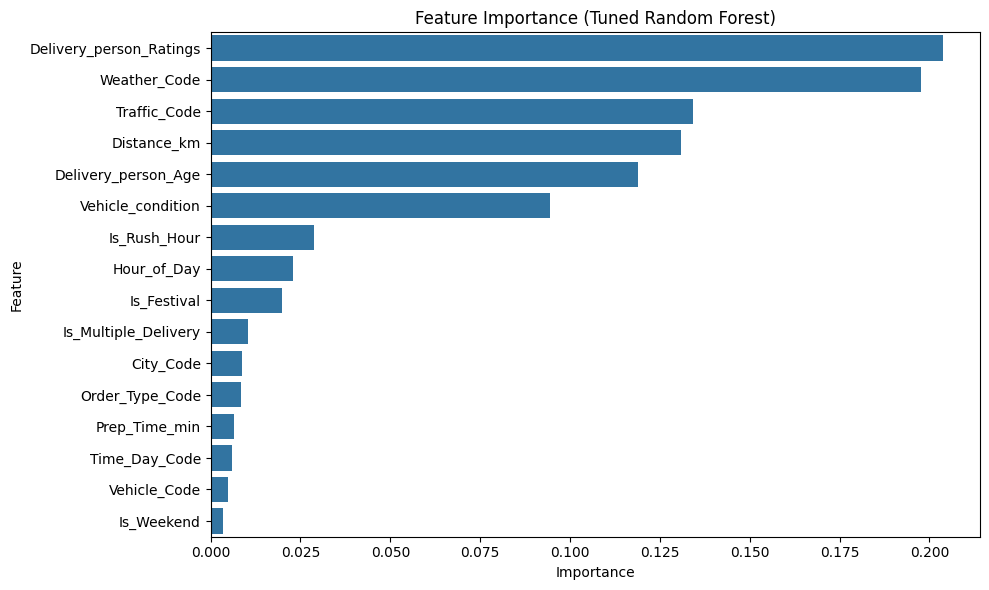

In [ ]:
# ── CELL 28  |  Feature Importance ───────────────────────────────────────────
# Use best_model (tuned, without Is_High_Rating) not rf_model

importances = pd.DataFrame({
    "feature": model_features,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=importances)
plt.title("Feature Importance (Tuned Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

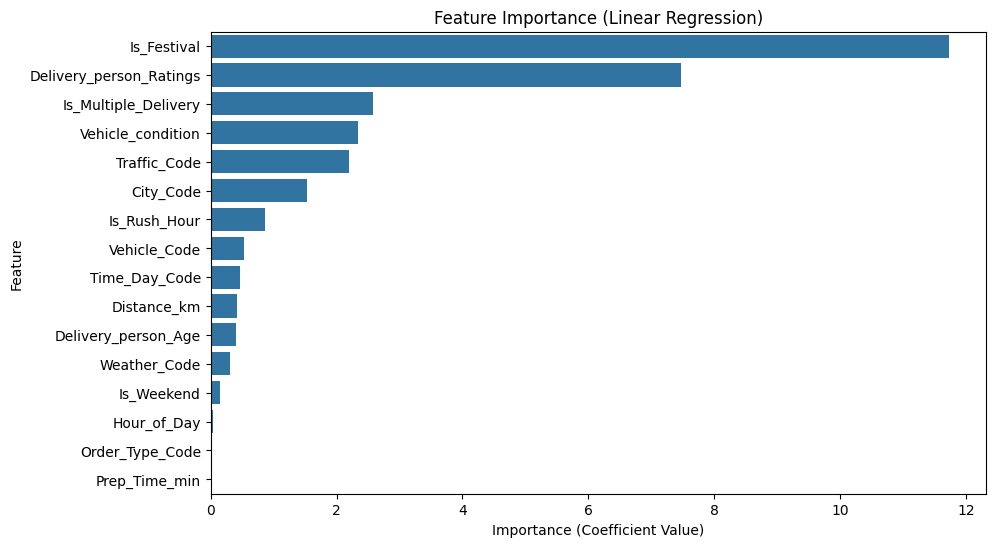

In [ ]:
# ── CELL 28B  |  Modeling & Evaluation - Explaining Feature Importance ───────────────────────
# LinearRegression

importances = pd.DataFrame({
    "feature": model_features,
    "importance": lr_model.coef_
}).sort_values("importance", ascending=False)

# absolute values of feature importance
importances["abs_importance"] = importances["importance"].abs()
importances = importances.sort_values("abs_importance", ascending=False)

# plotting this information
plt.figure(figsize=(10, 6))
sns.barplot(x="abs_importance", y="feature", data=importances)
plt.title("Feature Importance (Linear Regression)")
plt.xlabel("Importance (Coefficient Value)")
plt.ylabel("Feature")
plt.show()

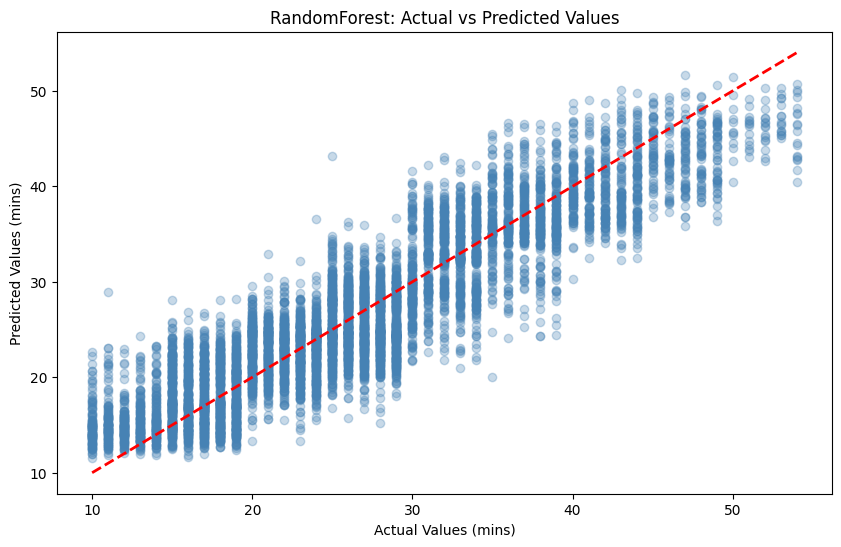

In [ ]:
# ── CELL 29  |  Modeling & Evaluation - Actual vs Predicted Values ───────────────────────

# plotting the actual vs predicted values on a scatter plot to compare and discuss the results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color="steelblue")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle="--", color="red", lw=2)
plt.xlabel("Actual Values (mins)")
plt.ylabel("Predicted Values (mins)")
plt.title("RandomForest: Actual vs Predicted Values")
plt.show()

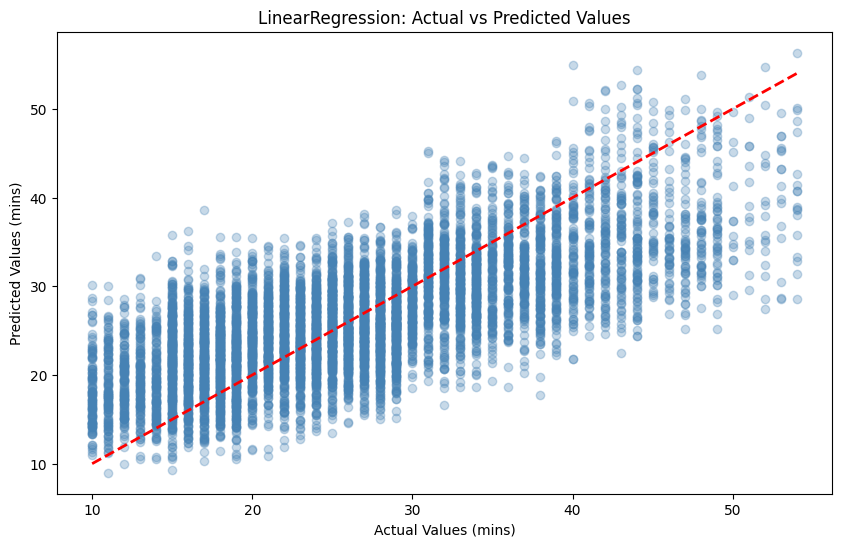

In [ ]:
# ── CELL 29  |  Modeling & Evaluation - Actual vs Predicted Values ───────────────────────

# plotting the actual vs predicted values on a scatter plot to compare and discuss the results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, lr_pred, alpha=0.3, color="steelblue")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle="--", color="red", lw=2)
plt.xlabel("Actual Values (mins)")
plt.ylabel("Predicted Values (mins)")
plt.title("LinearRegression: Actual vs Predicted Values")
plt.show()

In [ ]:
# ── CELL 31  |  Model Comparison ───────────────────────────────────────────────

# compare the two models used RandomForest and LinearRegression
comparison_data = {
   "Metric": ["Mean Absolute Error", "Root Mean Squared Error", "R-squared"],
   "RandomForest": [-mean_absolute_error(y_test, y_pred), np.sqrt(mean_squared_error(y_test, y_pred)), r2_score(y_test, y_pred)],
   "LinearRegression": [-mean_absolute_error(y_test, lr_pred), np.sqrt(mean_squared_error(y_test, lr_pred)), r2_score(y_test, lr_pred)]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

,Metric,RandomForest,LinearRegression
0,Mean Absolute Error,-3.130948,-5.167827
1,Root Mean Squared Error,3.907337,6.521187
2,R-squared,0.826145,0.515739


In [ ]:
# ── CELL 32  |  Save the Model ───────────────────────────────────────────────
import joblib
import json

# rf_model is your trained model from Cell 26
joblib.dump(rf_model, '/content/drive/MyDrive/best_rf_model.pkl')
joblib.dump(lr_model, '/content/drive/MyDrive/best_lr_model.pkl')

# Save the feature list
with open('/content/drive/MyDrive/model_features.json', 'w') as f:
    json.dump(model_features, f)


print("Saved successfully!")

Saved successfully!


In [ ]:
# ── CELL 33  |  GRADIO

import gradio as gr
import joblib
import numpy as np

model = joblib.load('/content/drive/MyDrive/best_rf_model.pkl')

def predict(distance, prep_time, weather, traffic, vehicle, city, festival, time_of_day, rating, multi):
    weather_map  = {'Sunny':0,'Cloudy':1,'Windy':2,'Fog':3,'Stormy':5}
    traffic_map  = {'Low':0,'Medium':1,'High':2,'Jam':3}
    vehicle_map  = {'Bicycle':0,'Scooter':1,'Motorcycle':2,'E-Scooter':3}
    city_map     = {'Semi-Urban':0,'Urban':1,'Metropolitan':2}
    tod_map      = {'Morning':0,'Afternoon':1,'Evening':2,'Night':3}

    features = [distance, prep_time, 12, 0, 0,  # distance, prep, hour, rush, weekend
                25, rating, 1 if rating>=4.7 else 0, 1 if multi else 0, 2,  # driver features
                weather_map[weather], traffic_map[traffic], vehicle_map[vehicle],
                city_map[city], tod_map[time_of_day], 2, 0 if festival=='No' else 1,
                distance/(rating+1)]  # efficiency index

    pred = model.predict([features])[0]
    return f"{round(pred)} minutes  (±3 min)"

demo = gr.Interface(
    fn=predict,
    inputs=[
        gr.Slider(1, 30, label="Distance (km)"),
        gr.Slider(1, 60, label="Prep time (min)"),
        gr.Dropdown(['Sunny','Cloudy','Windy','Fog','Stormy'], label="Weather"),
        gr.Dropdown(['Low','Medium','High','Jam'], label="Traffic"),
        gr.Dropdown(['Bicycle','Scooter','Motorcycle','E-Scooter'], label="Vehicle"),
        gr.Dropdown(['Semi-Urban','Urban','Metropolitan'], label="City"),
        gr.Radio(['No','Yes'], label="Festival day?"),
        gr.Dropdown(['Morning','Afternoon','Evening','Night'], label="Time of day"),
        gr.Slider(1.0, 5.0, value=4.5, label="Driver rating"),
        gr.Checkbox(label="Multiple deliveries?"),
    ],
    outputs=gr.Textbox(label="Predicted delivery time (NOT Including Prep Time)"),
    title="Food Delivery Time Predictor",
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://db2257c81acf5dbe1b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
joblib.dump(rf_model, '/content/drive/MyDrive/best_rf_model.pkl')

['/content/drive/MyDrive/best_rf_model.pkl']